<div style="text-align:center;">

<h1 style="color:#4aa3ff;">🌐 Phishing Website Detection using Machine Learning</h1>

<p style="color:lightgray; font-size:18px;">
Intelligent detection of malicious websites using URL and security-based features
</p>

<p style="color:lightgray; font-size:16px;">
Comparative analysis of multiple machine learning models to identify the most accurate solution
</p>

<hr style="border:1px solid gray;">

</div>

<div style="text-align:center;">

<hr>

<h2 style="color:#4aa3ff;">1️⃣ IMPORTING REQUIRED LIBRARIES</h2>

<p style="color:lightgray;">
Loading essential libraries for data processing, model training, evaluation, and visualization
</p>

<hr>

</div>

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

<div style="text-align:center;">

<hr style="border:1px solid gray;">

<h2 style="color:#4aa3ff;">2️⃣ DATA LOADING & OVERVIEW</h2>

<p style="color:lightgray; font-size:16px;">
Loading and exploring the phishing website dataset for analysis and model training
</p>

<p style="color:lightgray; font-size:14px;">
🌐 Dataset Source: 
<a href="https://www.kaggle.com/datasets/eswarchandt/phishing-website-detector" target="_blank" style="color:#4aa3ff;">
Kaggle - Phishing Website Dataset
</a>
</p>

<hr style="border:1px solid gray;">

</div>

In [2]:
df = pd.read_csv("phishing.csv")

print("Shape:", df.shape)
df.head()

Shape: (11054, 32)


,Index,UsingIP,LongURL,ShortURL,Symbol@,Redirecting//,PrefixSuffix-,SubDomains,HTTPS,DomainRegLen,...,UsingPopupWindow,IframeRedirection,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,LinksPointingToPage,StatsReport,class
0,0,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
1,1,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
2,2,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
3,3,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1
4,4,-1,0,-1,1,-1,-1,1,1,-1,...,1,1,1,1,1,-1,1,-1,-1,1


<div style="text-align:center;">

<hr>

<h2 style="color:#4aa3ff;">3️⃣ DATA PREPROCESSING & ANALYSIS</h2>

<p style="color:lightgray;">
Cleaning the dataset by removing unnecessary features and validating data quality
</p>

<p style="color:lightgray;">
Analyzing missing values and class distribution for better model reliability
</p>

<hr>

</div>

In [3]:
# Drop unnecessary column
df = df.drop(columns=['Index'])

# Check missing values
print(df.isnull().sum())

# Check class distribution
print(df['class'].value_counts())

UsingIP                0
LongURL                0
ShortURL               0
Symbol@                0
Redirecting//          0
PrefixSuffix-          0
SubDomains             0
HTTPS                  0
DomainRegLen           0
Favicon                0
NonStdPort             0
HTTPSDomainURL         0
RequestURL             0
AnchorURL              0
LinksInScriptTags      0
ServerFormHandler      0
InfoEmail              0
AbnormalURL            0
WebsiteForwarding      0
StatusBarCust          0
DisableRightClick      0
UsingPopupWindow       0
IframeRedirection      0
AgeofDomain            0
DNSRecording           0
WebsiteTraffic         0
PageRank               0
GoogleIndex            0
LinksPointingToPage    0
StatsReport            0
class                  0
dtype: int64
class
 1    6157
-1    4897
Name: count, dtype: int64


<div style="text-align:center;">

<hr>

<h2 style="color:#4aa3ff;">4️⃣ FEATURE & TARGET SEPARATION</h2>

<p style="color:lightgray;">
Separating input features and target variable for model training
</p>

<p style="color:lightgray;">
Converting class labels into binary format for better model compatibility
</p>

<hr>

</div>

In [4]:
X = df.drop('class', axis=1)
y = df['class']

# Convert labels (-1 → 0)
y = y.replace(-1, 0)

<div style="text-align:center;">

<hr>

<h2 style="color:#4aa3ff;">5️⃣ TRAIN-TEST DATA SPLITTING</h2>

<p style="color:lightgray;">
Dividing the dataset into training and testing sets for model evaluation
</p>

<p style="color:lightgray;">
Using 80% data for training and 20% for testing to ensure unbiased performance
</p>

<hr>

</div>

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

<div style="text-align:center;">

<hr>

<h2 style="color:#4aa3ff;">6️⃣ MODEL INITIALIZATION</h2>

<p style="color:lightgray;">
Initializing multiple machine learning models for performance comparison
</p>

<p style="color:lightgray;">
Each model is configured with standard parameters to ensure fair evaluation
</p>

<hr>

</div>

In [6]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

<div style="text-align:center;">

<hr>

<h2 style="color:#4aa3ff;">7️⃣ MODEL TRAINING & PERFORMANCE COMPARISON</h2>

<p style="color:lightgray;">
Training multiple machine learning models on the dataset
</p>

<p style="color:lightgray;">
Evaluating and comparing their accuracy to identify the best-performing model
</p>

<hr>

</div>

In [7]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"{name} Accuracy: {acc}")

Logistic Regression Accuracy: 0.9335142469470827
Random Forest Accuracy: 0.9706015377657169
XGBoost Accuracy: 0.9706015377657169


<div style="text-align:center;">

<hr>

<h2 style="color:#4aa3ff;">8️⃣ MODEL PERFORMANCE VISUALIZATION</h2>

<p style="color:lightgray;">
Visualizing the accuracy of different machine learning models using a bar chart
</p>

<p style="color:lightgray;">
This helps in clearly comparing model performance and identifying the best model
</p>

<hr>

</div>

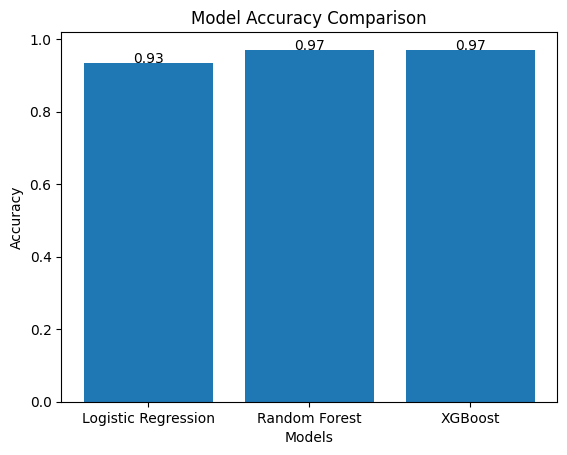

In [8]:
plt.figure()
plt.bar(results.keys(), results.values())
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

# Add values on bars
for i, v in enumerate(results.values()):
    plt.text(i, v, f"{v:.2f}", ha='center')

plt.show()

<div style="text-align:center;">

<hr>

<h2 style="color:#4aa3ff;">9️⃣ BEST MODEL SELECTION</h2>

<p style="color:lightgray;">
Identifying the best-performing model based on highest accuracy
</p>

<p style="color:lightgray;">
Selecting the most reliable model for final prediction and deployment
</p>

<hr>

</div>

In [9]:
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print("Best Model:", best_model_name)
print("Accuracy:", results[best_model_name])

Best Model: Random Forest
Accuracy: 0.9706015377657169


<div style="text-align:center;">

<hr>

<h2 style="color:#4aa3ff;">🔟 MODEL PREDICTION</h2>

<p style="color:lightgray;">
Using the selected best model to generate predictions on the test dataset
</p>

<p style="color:lightgray;">
Evaluating how well the model performs on unseen data
</p>

<hr>

</div>

In [10]:
y_pred = best_model.predict(X_test)

<div style="text-align:center;">

<hr>

<h2 style="color:#4aa3ff;">1️⃣1️⃣ MODEL EVALUATION (CLASSIFICATION REPORT)</h2>

<p style="color:lightgray;">
Evaluating model performance using key classification metrics
</p>

<p style="color:lightgray;">
Includes precision, recall, F1-score, and overall accuracy for detailed analysis
</p>

<hr>

</div>

In [11]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.96      0.97       976
           1       0.97      0.98      0.97      1235

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



<div style="text-align:center;">

<hr>

<h2 style="color:#4aa3ff;">1️⃣2️⃣ CONFUSION MATRIX ANALYSIS</h2>

<p style="color:lightgray;">
Visualizing model performance by comparing actual vs predicted classifications
</p>

<p style="color:lightgray;">
Helps identify correct predictions and classification errors in detail
</p>

<hr>

</div>

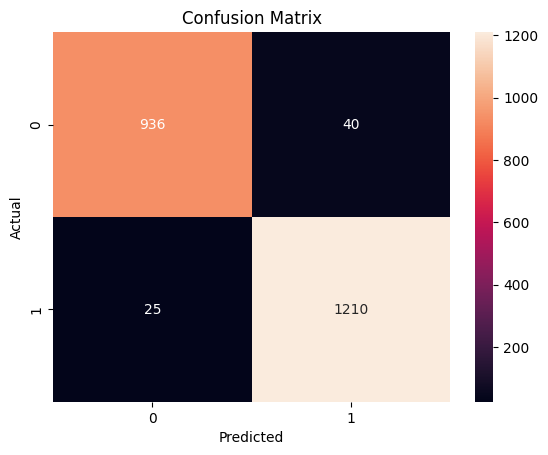

In [19]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

<div style="text-align:center;">

<hr>

<h2 style="color:#4aa3ff;">1️⃣3️⃣ MODEL SAVING & DEPLOYMENT READY</h2>

<p style="color:lightgray;">
Saving the trained model along with feature structure for future use
</p>

<p style="color:lightgray;">
Ensures seamless integration into real-world applications such as phishing detection systems
</p>

<hr>

</div>

In [20]:
model_data = {
    "model": best_model,
    "features": X.columns.tolist()
}

joblib.dump(model_data, "phishing_model_complete.pkl")

['phishing_model_complete.pkl']

<div style="text-align:center;">

<hr>

<h2 style="color:#4aa3ff;">🔄 MODEL LOADING FOR DEPLOYMENT</h2>

<p style="color:lightgray;">
Loading the saved model and feature structure for real-time prediction
</p>

<hr>

</div>

In [21]:
import joblib

data = joblib.load("phishing_model_complete.pkl")

model = data["model"]
features = data["features"]

## ✅ Final Conclusion

- Random Forest achieved the highest accuracy (~97%)
- Model shows strong performance with balanced precision and recall
- Suitable for real-world phishing website detection